In [51]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoModelForCausalLM
from tuned_lens import TunedLens

MODEL_NAME = "EleutherAI/pythia-160m-deduped"
DATA_DIR = Path("../token_evolution_data/excerpts")
N_LAYERS = 13  # layers 0-12: embedding + 12 transformer blocks

# Load model
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
model.float().eval()
final_ln = model.gpt_neox.final_layer_norm

# Load TunedLens (for Part 3: translated hidden states)
tuned_lens = TunedLens.from_model_and_pretrained(model, map_location="cpu").float()
tuned_lens.eval()
torch.set_grad_enabled(False)

print("Model and TunedLens loaded.")

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 1656.91it/s, Materializing param=gpt_neox.layers.11.post_attention_layernorm.weight] 


Model and TunedLens loaded.


In [52]:
excerpt_files = sorted(DATA_DIR.glob("excerpt_*.npz"))
print(f"Found {len(excerpt_files)} excerpts")

categories = ["never", "by_4", "by_0"]
cat_labels = {
    "never": "Never stabilize",
    "by_4": "Stable by layer 4",
    "by_0": "Stable by layer 0",
}

# Accumulators for average cosine similarity matrices
cos_sum_raw = {c: np.zeros((N_LAYERS, N_LAYERS)) for c in categories}
cos_sum_tl  = {c: np.zeros((N_LAYERS, N_LAYERS)) for c in categories}
token_count = {c: 0 for c in categories}


def accumulate_cos(h, acc):
    """Accumulate pairwise layer cosine similarities. h: (L, N, D), acc: (L, L)."""
    norms = np.linalg.norm(h, axis=2, keepdims=True) + 1e-10
    h_n = h / norms
    cos = np.einsum("ink,jnk->ijn", h_n, h_n)  # (L, L, N)
    acc += cos.sum(axis=2)


for fi, fpath in enumerate(excerpt_files):
    if fi % 200 == 0:
        print(f"  Processing {fi}/{len(excerpt_files)} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]          # (13, seq_len, 768)
    top_ids = data["tl_top_token_ids"]   # (13, seq_len)

    seq_len = hs.shape[1]
    end = seq_len - 1  # drop last token
    if end <= 0:
        continue

    # Writable float32 copy, dropping last token
    hs_work = np.array(hs[:, :end, :], dtype=np.float32)

    # NOTE: hidden_states[12] is already post-final-layer-norm (GPT-NeoX returns the
    # post-LN state as the last element of output_hidden_states). No need to apply
    # final_ln again.

    # ── Persistent top-1 layer (stabilization criterion) ──
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum, axis=0)   # (end,)

    masks = {
        "never": player == 12,   # top-1 only matches at the final layer
        "by_4":  player <= 4,    # stabilizes at or before layer 4
        "by_0":  player == 0,    # top-1 never changes across depth
    }

    # TunedLens translated hidden states
    hs_tl_arr = np.empty_like(hs_work)
    for l in range(12):
        h = torch.tensor(hs_work[l])  # layers 0-11 are un-modified raw states
        h_t = tuned_lens.transform_hidden(h, l)
        h_ln = tuned_lens.unembed.final_norm(h_t)
        hs_tl_arr[l] = h_ln.numpy()
    # Layer 12 is already post-final-LN, so just apply final_norm for consistency
    # (this is the identity-like operation since it's already been normed by the model)
    hs_tl_arr[12] = hs_work[12]

    # Accumulate cosine similarities by category
    for cat, mask in masks.items():
        n = int(mask.sum())
        if n == 0:
            continue
        token_count[cat] += n
        accumulate_cos(hs_work[:, mask, :],    cos_sum_raw[cat])
        accumulate_cos(hs_tl_arr[:, mask, :],  cos_sum_tl[cat])

# Compute mean cosine similarity matrices
cos_mean_raw = {c: cos_sum_raw[c] / max(token_count[c], 1) for c in categories}
cos_mean_tl  = {c: cos_sum_tl[c]  / max(token_count[c], 1) for c in categories}

print("\nToken counts per category:")
for c in categories:
    print(f"  {cat_labels[c]}: {token_count[c]:,}")
print("Done.")

Found 1605 excerpts
  Processing 0/1605 ...
  Processing 200/1605 ...
  Processing 400/1605 ...
  Processing 600/1605 ...
  Processing 800/1605 ...
  Processing 1000/1605 ...
  Processing 1200/1605 ...
  Processing 1400/1605 ...
  Processing 1600/1605 ...

Token counts per category:
  Never stabilize: 105,078
  Stable by layer 4: 33,737
  Stable by layer 0: 14,353
Done.


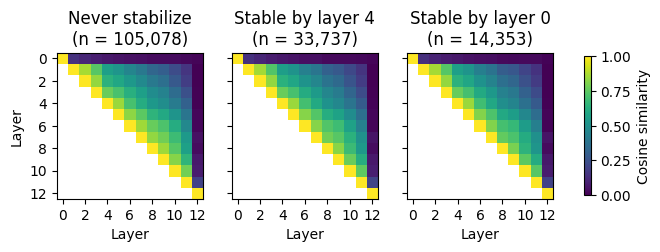

In [53]:

def plot_cossim_matrix(cos_mean_dict, categories, cat_labels, token_count):
    fig, axes = plt.subplots(1, 3, figsize=(8, 3), sharex=True, sharey=True)
    vmin, vmax = 0, 1

    for ax, c in zip(axes, categories):
        mat = cos_mean_dict[c].copy()
        mat[np.triu_indices(N_LAYERS, k=1)] = np.nan
        im = ax.imshow(mat.T, vmin=vmin, vmax=vmax, cmap="viridis", aspect="equal")
        ax.set_title(f"{cat_labels[c]}\n(n = {token_count[c]:,})")
        ax.set_xlabel("Layer")
        if ax is axes[0]:
            ax.set_ylabel("Layer")
        ax.set_xticks(range(0, N_LAYERS, 2))
        ax.set_yticks(range(0, N_LAYERS, 2))

    fig.colorbar(im, ax=axes, shrink=0.6, label="Cosine similarity", pad=0.05)
    return fig

fig2 = plot_cossim_matrix(cos_mean_raw, categories, cat_labels, token_count)
plt.savefig("../figures/raw_hidden_cossim_new.pdf", bbox_inches="tight")

This shows the cosine similarities between TunedLens "translated hidden states"

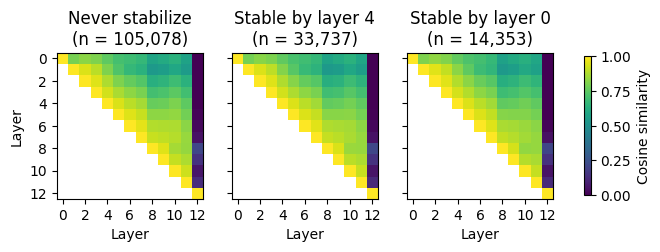

In [54]:
fig3 = plot_cossim_matrix(cos_mean_tl, categories, cat_labels, token_count)
plt.savefig("../figures/translated_hidden_cossim.pdf", bbox_inches="tight")

### Cosine similarity by model cross-entropy decile

Instead of splitting tokens by TunedLens top-1 stabilization layer, split them by the model's own cross-entropy loss. We compare the bottom decile (lowest CE — easiest tokens) vs. the top decile (highest CE — hardest tokens).

In [106]:
all_losses = []
for fi, fpath in enumerate(excerpt_files):
    data = np.load(fpath, allow_pickle=True)
    tl = data["token_losses"]  # (seq_len-1,)
    all_losses.append(tl)

all_losses = np.concatenate(all_losses)
print(f"Total tokens with losses: {len(all_losses):,}")
print(f"Loss range: [{all_losses.min():.4f}, {all_losses.max():.4f}]")

# Decile thresholds
lo_thresh = np.percentile(all_losses, 10)
hi_thresh = np.percentile(all_losses, 90)
print(f"Bottom decile (≤ {lo_thresh:.4f}): {(all_losses <= lo_thresh).sum():,} tokens")
print(f"Top decile    (≥ {hi_thresh:.4f}): {(all_losses >= hi_thresh).sum():,} tokens")

Total tokens with losses: 262,151
Loss range: [0.0000, 504.2500]
Bottom decile (≤ 0.2361): 26,219 tokens
Top decile    (≥ 8.3359): 26,275 tokens


In [ ]:
# ── Pass 2: Accumulate cosine similarity matrices for CE deciles ──
ce_categories = ["low_ce", "high_ce"]
cos_sum_ce = {c: np.zeros((N_LAYERS, N_LAYERS)) for c in ce_categories}
token_count_ce = {c: 0 for c in ce_categories}

for fi, fpath in enumerate(excerpt_files):
    if fi % 200 == 0:
        print(f"  Processing {fi}/{len(excerpt_files)} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]       # (13, seq_len, 768)
    tl = data["token_losses"]        # (seq_len-1,)

    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_work = np.array(hs[:, :end, :], dtype=np.float32)

    # Masks based on model cross-entropy
    ce_masks = {
        "low_ce":  tl <= lo_thresh,
        "high_ce": tl >= hi_thresh,
    }

    for cat, mask in ce_masks.items():
        n = int(mask.sum())
        if n == 0:
            continue
        token_count_ce[cat] += n
        accumulate_cos(hs_work[:, mask, :], cos_sum_ce[cat])

cos_mean_ce = {c: cos_sum_ce[c] / max(token_count_ce[c], 1) for c in ce_categories}

print(f"\nToken counts:  low CE = {token_count_ce['low_ce']:,},  high CE = {token_count_ce['high_ce']:,}")
print("Done.")

  Processing 0/1605 ...


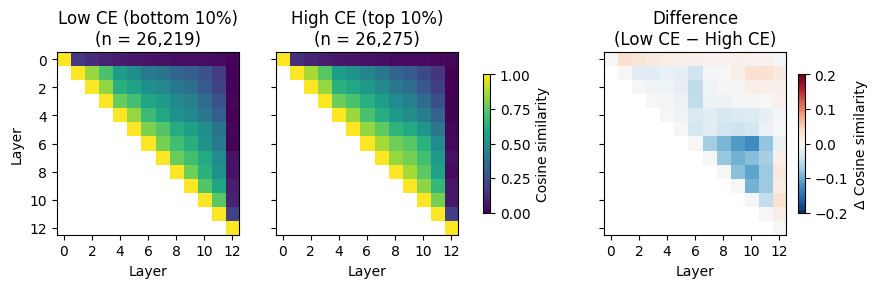

In [117]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True)

mat_lo = cos_mean_ce["low_ce"].copy()
mat_hi = cos_mean_ce["high_ce"].copy()
mat_diff = mat_lo - mat_hi  # positive = low-CE tokens more similar

# Mask upper triangle for display
tri_mask = np.triu_indices(N_LAYERS, k=1)

# Left: Low CE decile
mat_show = mat_lo.copy()
mat_show[tri_mask] = np.nan
im0 = axes[0].imshow(mat_show.T, vmin=0, vmax=1, cmap="viridis", aspect="equal")
axes[0].set_title(f"Low CE (bottom 10%)\n(n = {token_count_ce['low_ce']:,})")
axes[0].set_ylabel("Layer")

# Middle: High CE decile
mat_show = mat_hi.copy()
mat_show[tri_mask] = np.nan
im1 = axes[1].imshow(mat_show.T, vmin=0, vmax=1, cmap="viridis", aspect="equal")
axes[1].set_title(f"High CE (top 10%)\n(n = {token_count_ce['high_ce']:,})")

# Colorbar for left/middle
fig.colorbar(im1, ax=axes[:2], shrink=0.6, label="Cosine similarity", pad=0.05)

# Right: Difference (Low - High)
mat_show = mat_diff.copy()
mat_show[tri_mask] = np.nan
im2 = axes[2].imshow(mat_show.T, vmin=-0.2, vmax=0.2, cmap="RdBu_r", aspect="equal")
axes[2].set_title("Difference\n(Low CE − High CE)")
fig.colorbar(im2, ax=axes[2], shrink=0.6, label="Δ Cosine similarity", pad=0.05)

for ax in axes:
    ax.set_xlabel("Layer")
    ax.set_xticks(range(0, N_LAYERS, 2))
    ax.set_yticks(range(0, N_LAYERS, 2))

plt.savefig("../figures/raw_hidden_cossim_by_ce_decile.pdf", bbox_inches="tight")
plt.show()

In [113]:
# ── Recompute CE-decile cosine similarities with top-1 rogue dim removed ──
# Uses sorted_dims from the rogue dimension analysis (cell 13).
# sorted_dims[0] is the single dominant rogue dimension.

rogue_dim = sorted_dims[:1]
keep_dims = np.setdiff1d(np.arange(D_MODEL), rogue_dim)

cos_sum_ce_rm = {c: np.zeros((N_LAYERS, N_LAYERS)) for c in ce_categories}
token_count_ce_rm = {c: 0 for c in ce_categories}

for fi, fpath in enumerate(excerpt_files):
    if fi % 200 == 0:
        print(f"  Recomputing CE-decile (rogue removed) {fi}/{len(excerpt_files)} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]       # (13, seq_len, 768)
    tl = data["token_losses"]        # (seq_len-1,)

    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_work = np.array(hs[:, :end, :], dtype=np.float32)

    ce_masks = {
        "low_ce":  tl <= lo_thresh,
        "high_ce": tl >= hi_thresh,
    }

    for cat, mask in ce_masks.items():
        n = int(mask.sum())
        if n == 0:
            continue
        token_count_ce_rm[cat] += n
        accumulate_cos_subset(hs_work[:, mask, :], cos_sum_ce_rm[cat], keep_dims)

cos_mean_ce_rm = {c: cos_sum_ce_rm[c] / max(token_count_ce_rm[c], 1) for c in ce_categories}

print(f"\nToken counts (sanity):  low CE = {token_count_ce_rm['low_ce']:,},  high CE = {token_count_ce_rm['high_ce']:,}")
print(f"Rogue dimension removed: dim {rogue_dim[0]}")
print("Done.")

  Recomputing CE-decile (rogue removed) 0/1605 ...
  Recomputing CE-decile (rogue removed) 200/1605 ...
  Recomputing CE-decile (rogue removed) 400/1605 ...
  Recomputing CE-decile (rogue removed) 600/1605 ...
  Recomputing CE-decile (rogue removed) 800/1605 ...
  Recomputing CE-decile (rogue removed) 1000/1605 ...
  Recomputing CE-decile (rogue removed) 1200/1605 ...
  Recomputing CE-decile (rogue removed) 1400/1605 ...
  Recomputing CE-decile (rogue removed) 1600/1605 ...

Token counts (sanity):  low CE = 26,219,  high CE = 26,275
Rogue dimension removed: dim 429
Done.


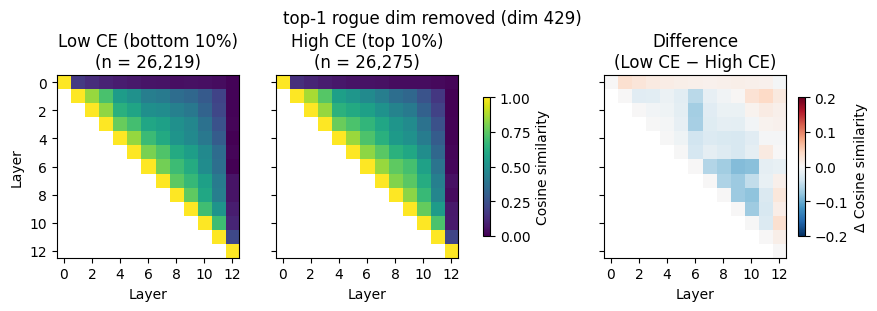

In [118]:
# ── 3-panel figure: CE deciles with rogue dim removed ──
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharex=True, sharey=True)

mat_lo = cos_mean_ce_rm["low_ce"].copy()
mat_hi = cos_mean_ce_rm["high_ce"].copy()
mat_diff = mat_lo - mat_hi

tri_mask = np.triu_indices(N_LAYERS, k=1)

# Left: Low CE decile
mat_show = mat_lo.copy()
mat_show[tri_mask] = np.nan
im0 = axes[0].imshow(mat_show.T, vmin=0, vmax=1, cmap="viridis", aspect="equal")
axes[0].set_title(f"Low CE (bottom 10%)\n(n = {token_count_ce_rm['low_ce']:,})")
axes[0].set_ylabel("Layer")

# Middle: High CE decile
mat_show = mat_hi.copy()
mat_show[tri_mask] = np.nan
im1 = axes[1].imshow(mat_show.T, vmin=0, vmax=1, cmap="viridis", aspect="equal")
axes[1].set_title(f"High CE (top 10%)\n(n = {token_count_ce_rm['high_ce']:,})")

fig.colorbar(im1, ax=axes[:2], shrink=0.6, label="Cosine similarity", pad=0.05)

# Right: Difference
mat_show = mat_diff.copy()
mat_show[tri_mask] = np.nan
im2 = axes[2].imshow(mat_show.T, vmin=-0.2, vmax=0.2, cmap="RdBu_r", aspect="equal")
axes[2].set_title("Difference\n(Low CE − High CE)")
fig.colorbar(im2, ax=axes[2], shrink=0.6, label="Δ Cosine similarity", pad=0.05)

for ax in axes:
    ax.set_xlabel("Layer")
    ax.set_xticks(range(0, N_LAYERS, 2))
    ax.set_yticks(range(0, N_LAYERS, 2))

fig.suptitle(f"top-1 rogue dim removed (dim {rogue_dim[0]})", y=1.02)
plt.savefig("../figures/raw_hidden_cossim_by_ce_decile_rogue_removed.pdf", bbox_inches="tight")
plt.show()

## Sanity check: does unembedding the translated hidden states recover the expected top-1 tokens?

For a subset of excerpts, we unembed each translated hidden state (apply the unembedding matrix) and check that the argmax matches `tl_top_token_ids` from the saved data.

In [55]:
# Sanity check: unembed translated hidden states and verify top-1 match
unembed_W = tuned_lens.unembed.unembedding  # nn.Linear (vocab_size, hidden_dim)

N_CHECK = 100  # number of excerpts to check
check_files = sorted(DATA_DIR.glob("excerpt_*.npz"))[:N_CHECK]

total_tokens_checked = 0
matches_per_layer = np.zeros(N_LAYERS, dtype=np.int64)
total_per_layer = np.zeros(N_LAYERS, dtype=np.int64)

for fpath in check_files:
    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]           # (13, seq_len, 768)
    top_ids = data["tl_top_token_ids"]   # (13, seq_len)
    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_f32 = np.array(hs[:, :end, :], dtype=np.float32)
    top_ref = top_ids[:, :end]  # (13, end)

    for l in range(12):
        h = torch.tensor(hs_f32[l])
        h_t = tuned_lens.transform_hidden(h, l)
        h_ln = tuned_lens.unembed.final_norm(h_t)
        logits = unembed_W(h_ln)  # (end, vocab_size)
        pred = logits.argmax(dim=-1).numpy()
        matches_per_layer[l] += (pred == top_ref[l]).sum()
        total_per_layer[l] += end

    # Final layer: hidden_states[12] is already post-final-layer-norm,
    # so unembed directly without applying final_norm again.
    h_final = torch.tensor(hs_f32[12])
    logits_final = unembed_W(h_final)
    pred_final = logits_final.argmax(dim=-1).numpy()
    matches_per_layer[12] += (pred_final == top_ref[12]).sum()
    total_per_layer[12] += end

    total_tokens_checked += end

acc = matches_per_layer / total_per_layer
print(f"Checked {N_CHECK} excerpts, {total_tokens_checked:,} tokens\n")
print("Layer | Top-1 match rate")
print("------+-----------------")
for l in range(N_LAYERS):
    print(f"  {l:2d}  |  {acc[l]:.6f}  ({matches_per_layer[l]}/{total_per_layer[l]})")

Checked 100 excerpts, 17,891 tokens

Layer | Top-1 match rate
------+-----------------
   0  |  0.996758  (17833/17891)
   1  |  0.998435  (17863/17891)
   2  |  0.998323  (17861/17891)
   3  |  0.998044  (17856/17891)
   4  |  0.998100  (17857/17891)
   5  |  0.997373  (17844/17891)
   6  |  0.997373  (17844/17891)
   7  |  0.995640  (17813/17891)
   8  |  0.985020  (17623/17891)
   9  |  0.992678  (17760/17891)
  10  |  0.996814  (17834/17891)
  11  |  0.994522  (17793/17891)
  12  |  0.890839  (15938/17891)


## Rogue dimensions analysis

We decompose the cosine similarity between layers into per-dimension contributions.
For a token with hidden states $h_i$ at layer $i$ and $h_j$ at layer $j$:

$$\cos(h_i, h_j) = \sum_d \frac{h_{i,d} \cdot h_{j,d}}{\|h_i\| \|h_j\|}$$

We compute the average contribution of each dimension to the inter-layer cosine similarity, then check whether a small number of "rogue dimensions" dominate.

In [104]:
D_MODEL = 768
N_SAMPLE = 1600  # excerpts to sample for this analysis

dimwise_sum = np.zeros((N_LAYERS, D_MODEL))  # avg contribution per dim at each layer-pair
pair_count = np.zeros(N_LAYERS)
# We compute: for each layer l, the mean per-dimension contribution to
# cos(h_l, h_{l+1}), i.e. adjacent-layer similarity.
# Also compute the global mean across ALL layer pairs.

global_dimwise = np.zeros(D_MODEL)
global_count = 0

sample_files = sorted(DATA_DIR.glob("excerpt_*.npz"))[:N_SAMPLE]

for fi, fpath in enumerate(sample_files):
    if fi % 50 == 0:
        print(f"  Rogue dim analysis: {fi}/{N_SAMPLE} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = np.array(data["hidden_states"][:, :-1, :], dtype=np.float32)  # (13, end, 768)
    n_tok = hs.shape[1]
    if n_tok <= 0:
        continue

    # Compute TunedLens translated states
    hs_tl = np.empty_like(hs)
    for l in range(12):
        h_t = tuned_lens.transform_hidden(torch.tensor(hs[l]), l)
        hs_tl[l] = tuned_lens.unembed.final_norm(h_t).numpy()
    hs_tl[12] = hs[12]

    # Norms per layer per token: (13, n_tok)
    norms = np.linalg.norm(hs_tl, axis=2, keepdims=True) + 1e-10  # (13, n_tok, 1)

    # For all layer pairs (i, j) with i < j:
    for i in range(N_LAYERS):
        for j in range(i + 1, N_LAYERS):
            norm_prod = (norms[i, :, 0] * norms[j, :, 0])  # (n_tok,)
            contrib = (hs_tl[i] * hs_tl[j]) / norm_prod[:, np.newaxis]  # (n_tok, 768)
            mean_contrib = contrib.mean(axis=0)  # (768,)
            global_dimwise += mean_contrib
            global_count += 1

# Average across all layer pairs and excerpts
global_dimwise /= global_count

# Sort dimensions by average contribution
sorted_dims = np.argsort(global_dimwise)[::-1]
cumulative = np.cumsum(global_dimwise[sorted_dims])
total_abs = cumulative[-1]

print("\nTop 10 dimensions by contribution to inter-layer cos sim (translated states):")
print(f"{'Rank':>4}  {'Dim':>4}  {'Contribution':>14}  {'Cum. frac':>10}")
for rank in range(10):
    d = sorted_dims[rank]
    print(f"{rank:4d}  {d:4d}  {global_dimwise[d]:+14.6f}  {cumulative[rank]/total_abs:10.4f}")

print(f"\nTotal absolute contribution sum: {total_abs:.6f}")
print(f"Top-5 dims account for {cumulative[4]/total_abs:.1%} of total |contribution|")

  Rogue dim analysis: 0/1600 ...
  Rogue dim analysis: 50/1600 ...
  Rogue dim analysis: 100/1600 ...
  Rogue dim analysis: 150/1600 ...
  Rogue dim analysis: 200/1600 ...
  Rogue dim analysis: 250/1600 ...
  Rogue dim analysis: 300/1600 ...
  Rogue dim analysis: 350/1600 ...
  Rogue dim analysis: 400/1600 ...
  Rogue dim analysis: 450/1600 ...
  Rogue dim analysis: 500/1600 ...
  Rogue dim analysis: 550/1600 ...
  Rogue dim analysis: 600/1600 ...
  Rogue dim analysis: 650/1600 ...
  Rogue dim analysis: 700/1600 ...
  Rogue dim analysis: 750/1600 ...
  Rogue dim analysis: 800/1600 ...
  Rogue dim analysis: 850/1600 ...
  Rogue dim analysis: 900/1600 ...
  Rogue dim analysis: 950/1600 ...
  Rogue dim analysis: 1000/1600 ...
  Rogue dim analysis: 1050/1600 ...
  Rogue dim analysis: 1100/1600 ...
  Rogue dim analysis: 1150/1600 ...
  Rogue dim analysis: 1200/1600 ...
  Rogue dim analysis: 1250/1600 ...
  Rogue dim analysis: 1300/1600 ...
  Rogue dim analysis: 1350/1600 ...
  Rogue dim ana

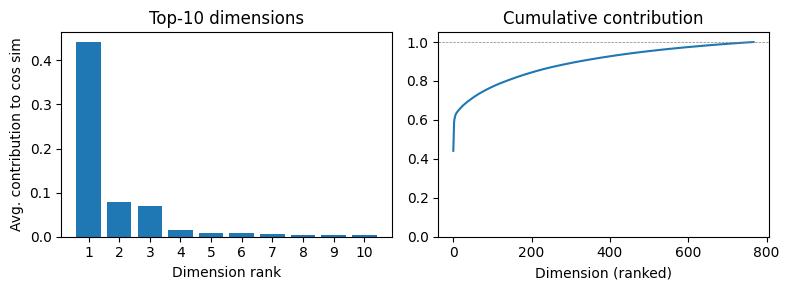

In [105]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# (a) Bar chart of top-10 dimension contributions
top_k = 10
ax = axes[0]
ax.bar(np.arange(top_k)+1, global_dimwise[sorted_dims[:top_k]] / total_abs)
ax.set_xlabel("Dimension rank")
ax.set_xticks(np.arange(1, top_k+1))
ax.set_ylabel("Avg. contribution to cos sim")
ax.set_title(f"Top-{top_k} dimensions")
ax.axhline(0, c="gray", lw=0.5, ls="--")

# (b) Cumulative contribution
ax = axes[1]
ax.plot(cumulative / total_abs)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Dimension (ranked)")
ax.set_title("Cumulative contribution")
ax.axhline(1.0, c="gray", lw=0.5, ls="--")

fig.tight_layout()
plt.savefig("../figures/rogue_dim_contributions.pdf", bbox_inches="tight")

## Recompute layer-wise cosine similarities with rogue dimensions removed

We remove the top-k rogue dimensions (k = 1, 3, 5) and recompute the translated-state cosine similarity matrices to see whether the lack of stabilization-dependence was an artifact of a few dominant dimensions.

In [ ]:
# ── Recompute cosine similarities with top-k rogue dims removed ──
K_VALUES = [1,]

# Precompute which dims to keep for each k
rogue_by_k = {k: sorted_dims[:k] for k in K_VALUES}
keep_by_k  = {k: np.setdiff1d(np.arange(D_MODEL), rogue_by_k[k]) for k in K_VALUES}

# Accumulators: cos_sum_tl_rm[k][cat] = (13, 13)
cos_sum_tl_rm = {k: {c: np.zeros((N_LAYERS, N_LAYERS)) for c in categories} for k in K_VALUES}
token_count_rm = {c: 0 for c in categories}  # same as token_count, recomputed as sanity check

def accumulate_cos_subset(h, acc, dims):
    """Like accumulate_cos but only uses dimensions in `dims`."""
    h_sub = h[:, :, dims]  # (L, N, len(dims))
    norms = np.linalg.norm(h_sub, axis=2, keepdims=True) + 1e-10
    h_n = h_sub / norms
    cos = np.einsum("ink,jnk->ijn", h_n, h_n)
    acc += cos.sum(axis=2)


for fi, fpath in enumerate(excerpt_files):
    if fi % 200 == 0:
        print(f"  Recomputing ({fi}/{len(excerpt_files)}) ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]
    top_ids = data["tl_top_token_ids"]
    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_work = np.array(hs[:, :end, :], dtype=np.float32)

    # Stabilization
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum, axis=0)

    masks = {
        "never": player == 12,
        "by_4":  player <= 4,
        "by_0":  player == 0,
    }

    # TunedLens translated states
    hs_tl_arr = np.empty_like(hs_work)
    for l in range(12):
        h_t = tuned_lens.transform_hidden(torch.tensor(hs_work[l]), l)
        hs_tl_arr[l] = tuned_lens.unembed.final_norm(h_t).numpy()
    hs_tl_arr[12] = hs_work[12]  # already post-LN

    for cat, mask in masks.items():
        n = int(mask.sum())
        if n == 0:
            continue
        token_count_rm[cat] += n
        h_masked = hs_tl_arr[:, mask, :]
        for k in K_VALUES:
            accumulate_cos_subset(h_masked, cos_sum_tl_rm[k][cat], keep_by_k[k])

cos_mean_tl_rm = {
    k: {c: cos_sum_tl_rm[k][c] / max(token_count_rm[c], 1) for c in categories}
    for k in K_VALUES
}

print("\nDone. Token counts (sanity check):")
for c in categories:
    print(f"  {cat_labels[c]}: {token_count_rm[c]:,}")

  Recomputing (0/1605) ...
  Recomputing (200/1605) ...
  Recomputing (400/1605) ...
  Recomputing (600/1605) ...
  Recomputing (800/1605) ...
  Recomputing (1000/1605) ...
  Recomputing (1200/1605) ...
  Recomputing (1400/1605) ...
  Recomputing (1600/1605) ...

Done. Token counts (sanity check):
  Never stabilize: 105,078
  Stable by layer 4: 33,737
  Stable by layer 0: 14,353


Removing the rogue dimensions (there is really one dimension that is "dominant") from the cosine similarity computation tends to lower the cosine similarity across depth, which makes sense. However, there is still no difference in the hidden state similarity evolution among different stabilization depths.


── Removing top-1 rogue dimension(s): dims [np.int64(429)] ──

── Removing top-3 rogue dimension(s): dims [np.int64(429), np.int64(684), np.int64(393)] ──

── Removing top-5 rogue dimension(s): dims [np.int64(429), np.int64(684), np.int64(393), np.int64(737), np.int64(177)] ──


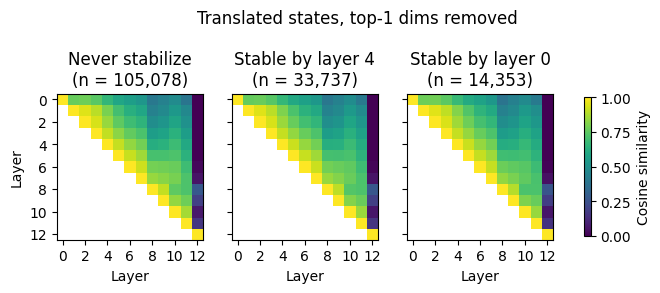

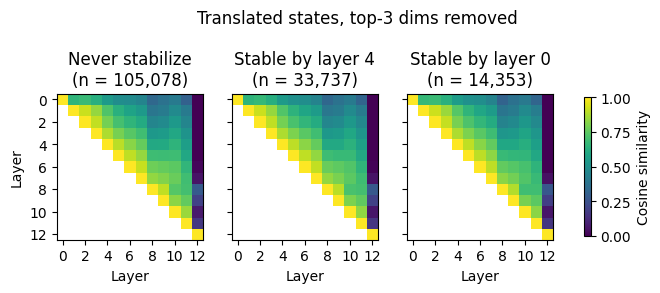

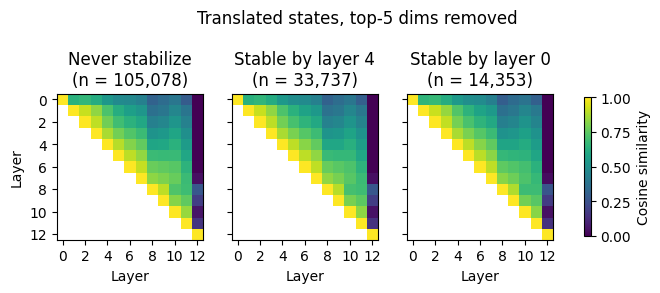

In [103]:
for k in K_VALUES:
    print(f"\n── Removing top-{k} rogue dimension(s): dims {list(rogue_by_k[k])} ──")
    fig = plot_cossim_matrix(cos_mean_tl_rm[k], categories, cat_labels, token_count_rm)
    fig.suptitle(f"Translated states, top-{k} dims removed", y=1.02)
    plt.savefig(f"../figures/translated_hidden_cossim_top-{k}_rogue_removed.pdf", bbox_inches="tight")

---
## Resolving the puzzle: why doesn't hidden-state cosine similarity differ by stabilization category?

**Observation:** Translated hidden state cosine similarity matrices look identical for "never stabilize," "stable by layer 4," and "stable by layer 0" tokens. Yet top-1 TunedLens predictions behave very differently across these groups.

**Key insight:** Top-1 prediction stability depends on $\arg\max_v \, w_v^\top h_l$, i.e., the ranking of 1D projections of $h$ onto each unembedding row $w_v$. Cosine similarity measures overall direction in the full 768-dim space. These are fundamentally different operations — changes in a tiny subspace can flip the argmax without affecting cosine similarity, and conversely, large overall direction changes can preserve the argmax if the margin is large.

### Hypotheses

**H1 — Logit margin:** Early-stabilizing tokens have large logit margins (gap between top-1 and top-2 logits) at every layer, making predictions robust to hidden state changes. Never-stabilizing tokens have small margins, so even similar-magnitude direction changes flip the ranking.

**H4 — Token characteristics:** Early-stabilizing tokens are simply "easy" tokens (function words, high-frequency, predictable context) with lower cross-entropy, not tokens whose hidden states evolve differently.

### H4 — Token-level statistics by stabilization category

Before testing mechanistic hypotheses, let's understand *what kinds of tokens* fall into each category: their identities, frequencies, and losses.

In [120]:
# ── H4: Aggregate token statistics by stabilization category ──
# With baseline normalization: we compute P(cat | token) / P(cat) to find tokens
# that are *disproportionately* in each category relative to their overall frequency.
from collections import Counter
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Accumulators
loss_by_cat = {c: [] for c in categories}
entropy_by_cat = {c: [] for c in categories}       # final-layer TunedLens entropy
token_id_counts = {c: Counter() for c in categories}
global_token_counts = Counter()  # baseline frequency across all tokens

for fi, fpath in enumerate(excerpt_files):
    if fi % 200 == 0:
        print(f"  Token stats: {fi}/{len(excerpt_files)} ...")

    data = np.load(fpath, allow_pickle=True)
    top_ids = data["tl_top_token_ids"]    # (13, seq_len)
    token_losses = data["token_losses"]   # (seq_len-1,)
    input_ids = data["input_ids"]         # (seq_len,)
    tl_entropy = data["tl_entropy"]       # (13, seq_len)

    seq_len = top_ids.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    # Stabilization (same as cell 2)
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum_match = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum_match, axis=0)

    masks = {
        "never": player == 12,
        "by_4":  player <= 4,
        "by_0":  player == 0,
    }

    # Count ALL target tokens for baseline
    for i in range(end):
        tid = int(input_ids[i + 1])
        global_token_counts[tid] += 1

    for cat, mask in masks.items():
        idx = np.where(mask)[0]
        if len(idx) == 0:
            continue
        loss_by_cat[cat].extend(token_losses[idx].tolist())
        entropy_by_cat[cat].extend(tl_entropy[12, idx].tolist())
        for i in idx:
            tid = int(input_ids[i + 1])
            token_id_counts[cat][tid] += 1

# ── Compute normalized over/under-representation ──
total_tokens = sum(global_token_counts.values())

print("\n" + "="*70)
print("TOKEN STATISTICS BY STABILIZATION CATEGORY")
print("="*70)

for c in categories:
    losses = np.array(loss_by_cat[c])
    entropies = np.array(entropy_by_cat[c])
    n_cat = len(losses)
    p_cat = n_cat / total_tokens  # P(cat)
    print(f"\n── {cat_labels[c]} (n = {n_cat:,}, {p_cat:.1%} of all tokens) ──")
    print(f"  Cross-entropy loss:  mean={losses.mean():.3f}, median={np.median(losses):.3f}, "
          f"std={losses.std():.3f}")
    print(f"  Final-layer entropy: mean={entropies.mean():.3f}, median={np.median(entropies):.3f}")

    # Top-10 by raw count
    print(f"\n  Top-10 target tokens (by raw count):")
    print(f"    {'Token':>15s}  {'Count':>6s}  {'% in cat':>8s}  {'% overall':>10s}  {'Lift':>6s}")
    for tok_id, count in token_id_counts[c].most_common(10):
        tok_str = tokenizer.decode([tok_id])
        pct_cat = count / n_cat * 100
        pct_global = global_token_counts[tok_id] / total_tokens * 100
        lift = (count / n_cat) / (global_token_counts[tok_id] / total_tokens)
        print(f"    {repr(tok_str):>15s}  {count:6d}  {pct_cat:7.1f}%  {pct_global:9.1f}%  {lift:6.2f}x")

    # Top-10 by lift (over-representation), filtering to tokens with >= 20 occurrences in cat
    print(f"\n  Top-10 target tokens (by lift = over-representation vs baseline):")
    print(f"    {'Token':>15s}  {'Count':>6s}  {'% in cat':>8s}  {'% overall':>10s}  {'Lift':>6s}")
    lifts = []
    for tok_id, count in token_id_counts[c].items():
        if count < 20:
            continue
        lift = (count / n_cat) / (global_token_counts[tok_id] / total_tokens)
        lifts.append((tok_id, count, lift))
    lifts.sort(key=lambda x: -x[2])
    for tok_id, count, lift in lifts[:10]:
        tok_str = tokenizer.decode([tok_id])
        pct_cat = count / n_cat * 100
        pct_global = global_token_counts[tok_id] / total_tokens * 100
        print(f"    {repr(tok_str):>15s}  {count:6d}  {pct_cat:7.1f}%  {pct_global:9.1f}%  {lift:6.2f}x")

print("\nDone.")

  Token stats: 0/1605 ...
  Token stats: 200/1605 ...
  Token stats: 400/1605 ...
  Token stats: 600/1605 ...
  Token stats: 800/1605 ...
  Token stats: 1000/1605 ...
  Token stats: 1200/1605 ...
  Token stats: 1400/1605 ...
  Token stats: 1600/1605 ...

TOKEN STATISTICS BY STABILIZATION CATEGORY

── Never stabilize (n = 105,078, 40.1% of all tokens) ──
  Cross-entropy loss:  mean=4.537, median=4.047, std=2.942
  Final-layer entropy: mean=4.695, median=4.824

  Top-10 target tokens (by raw count):
              Token   Count  % in cat   % overall    Lift
               ' .'    3225      3.1%        3.2%    0.95x
               ' ,'    3185      3.0%        4.0%    0.76x
             ' the'    3033      2.9%        5.1%    0.56x
             ' and'    1882      1.8%        2.1%    0.85x
              ' in'    1455      1.4%        1.7%    0.84x
              ' of'    1266      1.2%        2.4%    0.49x
              ' to'    1141      1.1%        1.8%    0.62x
               ' @'    112

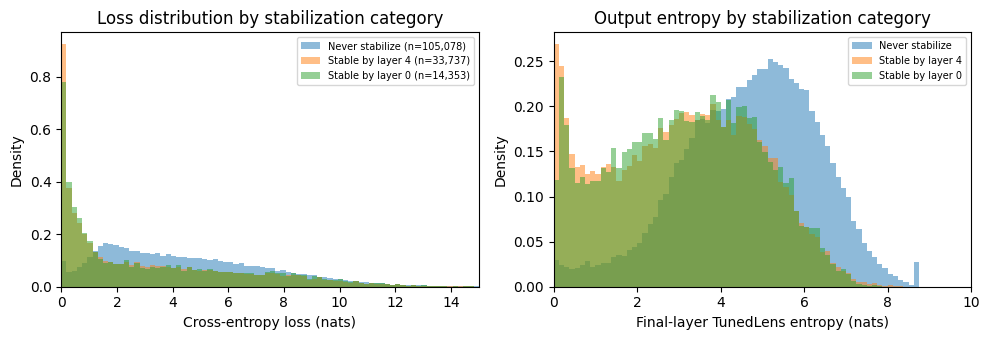

In [85]:
# ── H4 Visualization: Loss & entropy distributions by category ──
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# (a) Cross-entropy loss distributions
ax = axes[0]
for c in categories:
    losses = np.array(loss_by_cat[c])
    ax.hist(losses, bins=80, range=(0, 15), density=True, alpha=0.5,
            label=f"{cat_labels[c]} (n={len(losses):,})")
ax.set_xlabel("Cross-entropy loss (nats)")
ax.set_ylabel("Density")
ax.set_title("Loss distribution by stabilization category")
ax.legend(fontsize=7)
ax.set_xlim(0, 15)

# (b) Final-layer entropy distributions
ax = axes[1]
for c in categories:
    ent = np.array(entropy_by_cat[c])
    ax.hist(ent, bins=80, range=(0, 10), density=True, alpha=0.5,
            label=f"{cat_labels[c]}")
ax.set_xlabel("Final-layer TunedLens entropy (nats)")
ax.set_ylabel("Density")
ax.set_title("Output entropy by stabilization category")
ax.legend(fontsize=7)
ax.set_xlim(0, 10)

fig.tight_layout()
plt.savefig("../figures/token_stats_by_stabilization.pdf", bbox_inches="tight")
plt.show()

### H1 — Logit margin hypothesis

If the argmax is robust (large gap between top-1 and top-2 logits), the prediction can remain stable even as the hidden state direction changes. We compute the logit margin at each layer for each category.

The key quantity is the **logit margin**: $m_l = z_{l,(1)} - z_{l,(2)}$, where $z_{l,(1)}$ and $z_{l,(2)}$ are the largest and second-largest logits from the TunedLens at layer $l$.

If H1 is correct, early-stabilizing tokens should have consistently large margins, while never-stabilizing tokens should have small margins — explaining why prediction stability differs even though hidden-state cosine similarity does not.

In [86]:
# ── H1: Logit margin analysis by stabilization category ──
# For each token, compute logit margin (top1 - top2) at each layer via TunedLens.
# This requires computing full logits, which is expensive. We use a subset.

N_MARGIN = 400  # excerpts to analyze
margin_files = sorted(DATA_DIR.glob("excerpt_*.npz"))[:N_MARGIN]

# Accumulators: margin_sum[cat][layer], margin_count[cat]
margin_sum = {c: np.zeros(N_LAYERS) for c in categories}
margin_count = {c: np.zeros(N_LAYERS) for c in categories}

# Also track norms of translated hidden states
norm_sum = {c: np.zeros(N_LAYERS) for c in categories}
norm_count = {c: np.zeros(N_LAYERS) for c in categories}

for fi, fpath in enumerate(margin_files):
    if fi % 100 == 0:
        print(f"  Logit margin: {fi}/{N_MARGIN} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]
    top_ids = data["tl_top_token_ids"]
    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_f32 = np.array(hs[:, :end, :], dtype=np.float32)

    # Stabilization
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum_match = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum_match, axis=0)

    masks = {
        "never": player == 12,
        "by_4":  player <= 4,
        "by_0":  player == 0,
    }

    # Compute translated hidden states and logits at each layer
    for l in range(N_LAYERS):
        h = torch.tensor(hs_f32[l])
        if l < 12:
            h_t = tuned_lens.transform_hidden(h, l)
            h_ln = tuned_lens.unembed.final_norm(h_t)
        else:
            h_ln = h  # layer 12 is already post-LN

        # Compute logits
        logits = unembed_W(h_ln)  # (end, vocab_size)
        # Top-2 logits
        top2_vals, _ = torch.topk(logits, k=2, dim=-1)  # (end, 2)
        margins = (top2_vals[:, 0] - top2_vals[:, 1]).numpy()  # (end,)

        # Norms
        h_norms = np.linalg.norm(h_ln.numpy(), axis=1)  # (end,)

        for cat, mask in masks.items():
            n = int(mask.sum())
            if n == 0:
                continue
            margin_sum[cat][l] += margins[mask].sum()
            margin_count[cat][l] += n
            norm_sum[cat][l] += h_norms[mask].sum()
            norm_count[cat][l] += n

# Compute means
margin_mean = {c: margin_sum[c] / np.maximum(margin_count[c], 1) for c in categories}
norm_mean = {c: norm_sum[c] / np.maximum(norm_count[c], 1) for c in categories}

print("\nLogit margin (top1 - top2) by layer and category:")
print(f"{'Layer':>5}", end="")
for c in categories:
    print(f"  {cat_labels[c]:>20s}", end="")
print()
for l in range(N_LAYERS):
    print(f"  {l:3d}", end="")
    for c in categories:
        print(f"  {margin_mean[c][l]:20.3f}", end="")
    print()

print(f"\nTokens per category: ", {cat_labels[c]: int(margin_count[c][0]) for c in categories})

  Logit margin: 0/400 ...
  Logit margin: 100/400 ...
  Logit margin: 200/400 ...
  Logit margin: 300/400 ...

Logit margin (top1 - top2) by layer and category:
Layer       Never stabilize     Stable by layer 4     Stable by layer 0
    0                 0.580                 0.729                 1.022
    1                 0.529                 0.858                 1.137
    2                 0.570                 0.963                 1.282
    3                 0.593                 1.170                 1.503
    4                 0.645                 1.405                 1.686
    5                 0.662                 1.654                 1.722
    6                 0.633                 1.708                 1.750
    7                 0.671                 1.885                 1.896
    8                 0.703                 2.037                 2.019
    9                 0.697                 2.117                 2.133
   10                 0.703                 2.3

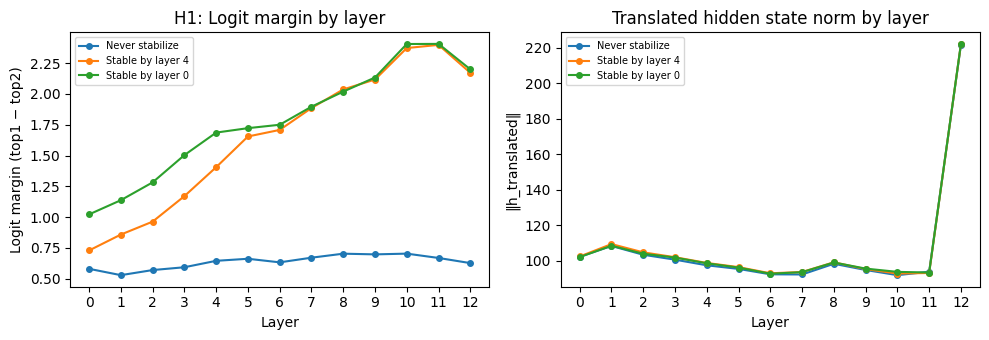

In [87]:
# ── H1 Visualization: Logit margin and norm by layer ──
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
layers = np.arange(N_LAYERS)

# (a) Logit margin by layer
ax = axes[0]
for c in categories:
    ax.plot(layers, margin_mean[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer")
ax.set_ylabel("Logit margin (top1 − top2)")
ax.set_title("H1: Logit margin by layer")
ax.legend(fontsize=7)
ax.set_xticks(layers)

# (b) Norm of translated hidden states by layer
ax = axes[1]
for c in categories:
    ax.plot(layers, norm_mean[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer")
ax.set_ylabel("‖h_translated‖")
ax.set_title("Translated hidden state norm by layer")
ax.legend(fontsize=7)
ax.set_xticks(layers)

fig.tight_layout()
plt.savefig("../figures/logit_margin_by_layer.pdf", bbox_inches="tight")
plt.show()

### Interim synthesis

The puzzle arises from conflating two different notions of "change":

1. **Hidden-state direction change** (measured by cosine similarity in $\mathbb{R}^{768}$): How much does the overall direction of the translated hidden state vector change between layers? This is a full-space measure over 768 dimensions.

2. **Prediction change** (measured by argmax stability after unembedding): Does the rank ordering of ~50K logits change? This depends only on which of the 50K 1D projections $w_v^\top h$ is largest — an extreme dimensionality reduction followed by a discontinuous (argmax) operation.

**Resolution — the logit margin (H1) is the primary explanation:**

The results show a clear 3–4× difference in logit margins between "never stabilize" (~0.6 nats gap) and "stable by layer 0" (~1.0–2.4 nats gap) tokens at every layer. Since the hidden state direction changes are similar for both groups (confirmed by the cosine similarity matrices), the difference in prediction stability is entirely explained by margin:
- For **high-margin tokens**, the same-magnitude direction change in $h$ produces a logit change smaller than the margin → prediction stays the same
- For **low-margin tokens**, the same-magnitude direction change crosses the decision boundary → prediction flips

**H4 (token statistics)**: Early-stabilizing tokens are disproportionately function words. They have lower cross-entropy and lower final-layer entropy — tokens where the model is confident from the start (high embedding-level margin).

**Next:** We verify this directly by computing the logit updates $\Delta \ell = W \Delta h$ at each layer transition, since unembedding is a linear projection. If the margin story is correct, the magnitude of logit updates should be similar across categories — what differs is how those updates relate to the margin.

In [94]:
# ── Collect translated hidden states for structure analyses ──
# We gather a balanced subsample of tokens from each category.

from sklearn.decomposition import PCA

N_PCA = 600  # excerpts to process
MAX_PER_CAT = 5000  # max tokens per category (for tractable PCA)

pca_files = sorted(DATA_DIR.glob("excerpt_*.npz"))[:N_PCA]

# Collect: for each category, store translated hidden states at each layer
# states_by_cat[cat] = list of (N_LAYERS, D_MODEL) arrays, one per token
states_by_cat = {c: [] for c in categories}

for fi, fpath in enumerate(pca_files):
    if fi % 100 == 0:
        print(f"  Collecting states: {fi}/{N_PCA} ...")
    # Check if we have enough
    if all(len(states_by_cat[c]) >= MAX_PER_CAT for c in categories):
        break

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]
    top_ids = data["tl_top_token_ids"]
    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_f32 = np.array(hs[:, :end, :], dtype=np.float32)

    # Stabilization
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum_match = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum_match, axis=0)

    masks = {
        "never": player == 12,
        "by_4":  player <= 4,
        "by_0":  player == 0,
    }

    # Compute translated hidden states
    hs_tl = np.empty_like(hs_f32)
    for l in range(12):
        h_t = tuned_lens.transform_hidden(torch.tensor(hs_f32[l]), l)
        hs_tl[l] = tuned_lens.unembed.final_norm(h_t).numpy()
    hs_tl[12] = hs_f32[12]

    for cat, mask in masks.items():
        if len(states_by_cat[cat]) >= MAX_PER_CAT:
            continue
        idx = np.where(mask)[0]
        for i in idx:
            if len(states_by_cat[cat]) >= MAX_PER_CAT:
                break
            states_by_cat[cat].append(hs_tl[:, i, :])  # (13, 768)

# Stack into arrays
states_arr = {}  # states_arr[cat] = (n_tokens, N_LAYERS, D_MODEL)
for c in categories:
    states_arr[c] = np.stack(states_by_cat[c])

print("\nCollected tokens:")
for c in categories:
    print(f"  {cat_labels[c]}: {states_arr[c].shape[0]}")
print("Done.")


Collected tokens:
  Never stabilize: 5000
  Stable by layer 4: 5000
  Stable by layer 0: 5000
Done.


Linear probe accuracy (never vs by_0):
Layer    Accuracy
    0    0.7946
    1    0.8019
    2    0.8045
    3    0.8030
    4    0.8167
    5    0.8102
    6    0.8097
    7    0.8041
    8    0.8073
    9    0.8149
   10    0.8037
   11    0.8101
   12    0.7659

Full trajectory (13×768):  0.8415
Chance level: 0.5000


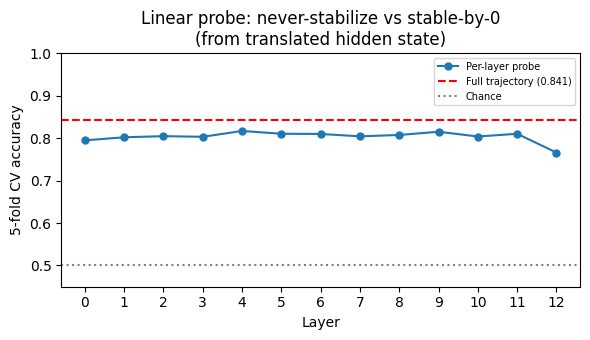

In [129]:
# can we predict stabilization from hidden state? 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Binary task: "never" vs "by_0" (most extreme pair)
# Use up to N_PROBE tokens from each category for tractability
N_PROBE = 10000
X_never = states_arr["never"][:N_PROBE]  # (N_PROBE, 13, 768)
X_by0   = states_arr["by_0"][:N_PROBE]

probe_acc = np.zeros(N_LAYERS)

for layer in range(N_LAYERS):
    X = np.concatenate([X_never[:, layer, :], X_by0[:, layer, :]], axis=0)
    y = np.concatenate([np.zeros(len(X_never)), np.ones(len(X_by0))])
    
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500, C=1.0))
    scores = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
    probe_acc[layer] = scores.mean()

# Also try on the full trajectory (concatenate all layers)
X_traj = np.concatenate([
    X_never.reshape(len(X_never), -1),
    X_by0.reshape(len(X_by0), -1)
], axis=0)
y_traj = np.concatenate([np.zeros(len(X_never)), np.ones(len(X_by0))])
clf_traj = make_pipeline(StandardScaler(), LogisticRegression(max_iter=500, C=1.0))
traj_scores = cross_val_score(clf_traj, X_traj, y_traj, cv=5, scoring="accuracy")

print("Linear probe accuracy (never vs by_0):")
print(f"{'Layer':>5}  {'Accuracy':>10}")
for l in range(N_LAYERS):
    print(f"  {l:3d}    {probe_acc[l]:.4f}")
print(f"\nFull trajectory (13×768):  {traj_scores.mean():.4f}")
print(f"Chance level: 0.5000")

# Plot
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(range(N_LAYERS), probe_acc, "o-", markersize=5, label="Per-layer probe")
ax.axhline(traj_scores.mean(), ls="--", c="red", label=f"Full trajectory ({traj_scores.mean():.3f})")
ax.axhline(0.5, ls=":", c="gray", label="Chance")
ax.set_xlabel("Layer")
ax.set_ylabel("5-fold CV accuracy")
ax.set_title("Linear probe: never-stabilize vs stable-by-0\n(from translated hidden state)")
ax.legend(fontsize=7)
ax.set_xticks(range(N_LAYERS))
ax.set_ylim(0.45, 1.0)
fig.tight_layout()
plt.savefig("../figures/linear_probe_stabilization.pdf", bbox_inches="tight")
plt.show()

### Logit updates via $W \Delta h$

Since unembedding is a linear projection $\ell = Wh$, the change in logits between adjacent layers is exactly $\Delta \ell = W \Delta h$. This lets us directly characterize how the model's output distribution evolves.

We compute three metrics for each category and layer transition $l \to l+1$:
1. **$\|\Delta \ell\|$ (L2 norm of logit update):** Total magnitude of logit changes — are hidden state updates producing equally large logit perturbations across categories?
2. **Logit update at top-1 token** — the signed change in the logit of the *final-layer* prediction. Positive = reinforcing the eventual answer.
3. **Ratio $\|\Delta \ell\| / \text{margin}$**: How large is the logit perturbation relative to the decision margin? If > 1, the update is large enough to potentially flip the prediction.

In [121]:
# ── Logit updates: Δℓ = W·Δh for each layer transition ──
# We compute translated hidden states at each layer, then Δh = h_{l+1} - h_l
# in the translated space, and map to logit space via the unembedding matrix.

N_LOGIT_UPDATE = 400  # excerpts to process
logit_update_files = sorted(DATA_DIR.glob("excerpt_*.npz"))[:N_LOGIT_UPDATE]

# Accumulators per category per layer-transition (12 transitions: 0→1, 1→2, ..., 11→12)
n_transitions = N_LAYERS - 1  # 12

# Metrics:
dl_norm_sum = {c: np.zeros(n_transitions) for c in categories}    # ‖Δℓ‖
dl_top1_sum = {c: np.zeros(n_transitions) for c in categories}    # Δℓ at top-1 token
dl_ratio_sum = {c: np.zeros(n_transitions) for c in categories}   # ‖Δℓ‖ / margin
dl_count = {c: np.zeros(n_transitions) for c in categories}

W = W_np  # (vocab_size, hidden_dim)

for fi, fpath in enumerate(logit_update_files):
    if fi % 100 == 0:
        print(f"  Logit updates: {fi}/{N_LOGIT_UPDATE} ...")

    data = np.load(fpath, allow_pickle=True)
    hs = data["hidden_states"]        # (13, seq_len, 768)
    top_ids = data["tl_top_token_ids"] # (13, seq_len)
    seq_len = hs.shape[1]
    end = seq_len - 1
    if end <= 0:
        continue

    hs_f32 = np.array(hs[:, :end, :], dtype=np.float32)

    # Stabilization
    top_work = top_ids[:, :end]
    matches = top_work == top_work[-1:]
    cum_match = np.cumprod(matches[::-1], axis=0)[::-1]
    player = np.argmax(cum_match, axis=0)

    masks = {
        "never": player == 12,
        "by_4":  player <= 4,
        "by_0":  player == 0,
    }

    # Compute translated hidden states at each layer
    hs_tl = np.empty_like(hs_f32)
    for l in range(12):
        h_t = tuned_lens.transform_hidden(torch.tensor(hs_f32[l]), l)
        hs_tl[l] = tuned_lens.unembed.final_norm(h_t).numpy()
    hs_tl[12] = hs_f32[12]  # layer 12 is final

    # Final-layer top-1 token ids (the "eventual answer")
    final_top1 = top_ids[12, :end]  # (end,)

    for t in range(n_transitions):
        # Δh in translated space
        delta_h = hs_tl[t + 1] - hs_tl[t]  # (end, 768)

        # Δℓ = W · Δh  (end, vocab) = (end, 768) @ (768, vocab)
        delta_logits = delta_h @ W.T  # (end, vocab_size)

        # ‖Δℓ‖ per token
        dl_norms = np.linalg.norm(delta_logits, axis=1)  # (end,)

        # Δℓ at the final-layer top-1 token
        dl_at_top1 = delta_logits[np.arange(end), final_top1]  # (end,)

        # Margin at layer t (for ratio)
        logits_t = hs_tl[t] @ W.T  # (end, vocab)
        top2_idx = np.argpartition(logits_t, -2, axis=1)[:, -2:]
        top2_vals = np.take_along_axis(logits_t, top2_idx, axis=1)
        margin_t = np.abs(top2_vals[:, 1] - top2_vals[:, 0])  # (end,)
        ratio = dl_norms / np.maximum(margin_t, 1e-8)

        for cat, mask in masks.items():
            n = int(mask.sum())
            if n == 0:
                continue
            dl_norm_sum[cat][t] += dl_norms[mask].sum()
            dl_top1_sum[cat][t] += dl_at_top1[mask].sum()
            dl_ratio_sum[cat][t] += ratio[mask].sum()
            dl_count[cat][t] += n

# Compute means
dl_norm_mean = {c: dl_norm_sum[c] / np.maximum(dl_count[c], 1) for c in categories}
dl_top1_mean = {c: dl_top1_sum[c] / np.maximum(dl_count[c], 1) for c in categories}
dl_ratio_mean = {c: dl_ratio_sum[c] / np.maximum(dl_count[c], 1) for c in categories}

print("\n‖Δℓ‖ (logit update norm) by layer transition and category:")
print(f"{'Trans':>6}", end="")
for c in categories:
    print(f"  {cat_labels[c]:>20s}", end="")
print()
for t in range(n_transitions):
    print(f"  {t}→{t+1}", end="")
    for c in categories:
        print(f"  {dl_norm_mean[c][t]:20.3f}", end="")
    print()

print(f"\nΔℓ at final top-1 (signed, mean) by layer transition:")
print(f"{'Trans':>6}", end="")
for c in categories:
    print(f"  {cat_labels[c]:>20s}", end="")
print()
for t in range(n_transitions):
    print(f"  {t}→{t+1}", end="")
    for c in categories:
        print(f"  {dl_top1_mean[c][t]:20.3f}", end="")
    print()

print(f"\n‖Δℓ‖ / margin ratio by layer transition:")
print(f"{'Trans':>6}", end="")
for c in categories:
    print(f"  {cat_labels[c]:>20s}", end="")
print()
for t in range(n_transitions):
    print(f"  {t}→{t+1}", end="")
    for c in categories:
        print(f"  {dl_ratio_mean[c][t]:20.3f}", end="")
    print()

print(f"\nTokens per category: ", {cat_labels[c]: int(dl_count[c][0]) for c in categories})

  Logit updates: 0/400 ...
  Logit updates: 100/400 ...
  Logit updates: 200/400 ...
  Logit updates: 300/400 ...

‖Δℓ‖ (logit update norm) by layer transition and category:
 Trans       Never stabilize     Stable by layer 4     Stable by layer 0
  0→1               879.684               886.106               792.776
  1→2               645.307               633.025               604.436
  2→3               578.054               551.488               512.609
  3→4               536.117               521.096               514.889
  4→5               914.235               832.317               810.289
  5→6               876.273               893.225               879.032
  6→7              1551.248              1959.685              1972.882
  7→8             12177.505             12283.785             12144.960
  8→9              5836.937              5810.783              5886.955
  9→10              7120.871              7608.963              7394.151
  10→11              3804.464   

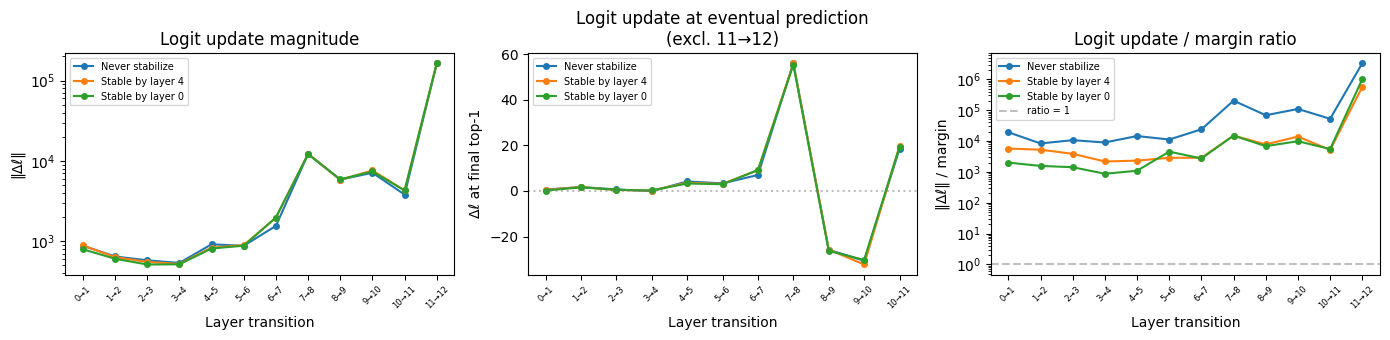

In [123]:
# ── Visualization: Logit updates by category ──
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
transitions = np.arange(n_transitions)
trans_labels = [f"{t}→{t+1}" for t in range(n_transitions)]

# (a) ‖Δℓ‖ norm (log scale)
ax = axes[0]
for c in categories:
    ax.plot(transitions, dl_norm_mean[c], "o-", markersize=4, label=cat_labels[c])
ax.set_xlabel("Layer transition")
ax.set_ylabel("‖Δℓ‖")
ax.set_title("Logit update magnitude")
ax.set_yscale("log")
ax.legend(fontsize=7)
ax.set_xticks(transitions)
ax.set_xticklabels(trans_labels, rotation=45, fontsize=6)

# (b) Δℓ at final top-1 (excluding last transition to see detail)
ax = axes[1]
for c in categories:
    ax.plot(transitions[:-1], dl_top1_mean[c][:-1], "o-", markersize=4, label=cat_labels[c])
ax.axhline(0, ls=":", c="gray", alpha=0.5)
ax.set_xlabel("Layer transition")
ax.set_ylabel("Δℓ at final top-1")
ax.set_title("Logit update at eventual prediction\n(excl. 11→12)")
ax.legend(fontsize=7)
ax.set_xticks(transitions[:-1])
ax.set_xticklabels(trans_labels[:-1], rotation=45, fontsize=6)

# (c) ‖Δℓ‖ / margin ratio (log scale)
ax = axes[2]
for c in categories:
    ax.plot(transitions, dl_ratio_mean[c], "o-", markersize=4, label=cat_labels[c])
ax.axhline(1.0, ls="--", c="gray", alpha=0.5, label="ratio = 1")
ax.set_xlabel("Layer transition")
ax.set_ylabel("‖Δℓ‖ / margin")
ax.set_title("Logit update / margin ratio")
ax.set_yscale("log")
ax.legend(fontsize=7)
ax.set_xticks(transitions)
ax.set_xticklabels(trans_labels, rotation=45, fontsize=6)

fig.tight_layout()
plt.savefig("../figures/logit_updates_by_category.pdf", bbox_inches="tight")
plt.show()